In [21]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

đọc dữ liệu từ dataset

In [22]:
red_wine_df = pd.read_csv("..\\..\\dataset\\winequality-red.csv", sep=";")

In [23]:
print(red_wine_df.shape)
red_wine_df.head()
red_wine_df.info()
red_wine_df.describe()

(1599, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


OUTLIERS

In [24]:
Q1 = red_wine_df['alcohol'].quantile(0.25)
Q3 = red_wine_df['alcohol'].quantile(0.75)
IQR = Q3 - Q1

outliers = red_wine_df[(red_wine_df['alcohol'] < Q1 - 1.5*IQR) |
                       (red_wine_df['alcohol'] > Q3 + 1.5*IQR)]

print(outliers)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
142             5.2              0.34         0.00             1.8      0.050   
144             5.2              0.34         0.00             1.8      0.050   
467             8.8              0.46         0.45             2.6      0.065   
588             5.0              0.42         0.24             2.0      0.060   
652            15.9              0.36         0.65             7.5      0.096   
821             4.9              0.42         0.00             2.1      0.048   
1114            5.0              0.40         0.50             4.3      0.046   
1132            7.4              0.36         0.34             1.8      0.075   
1228            5.1              0.42         0.00             1.8      0.044   
1269            5.5              0.49         0.03             1.8      0.044   
1270            5.0              0.38         0.01             1.6      0.048   
1475            5.3         

<Axes: xlabel='quality', ylabel='count'>

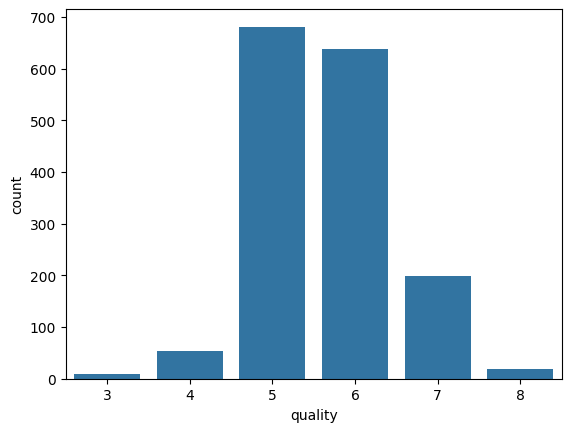

In [25]:
sns.countplot(x="quality", data=red_wine_df)

In [26]:
print(red_wine_df['quality'].describe())
print(red_wine_df['quality'].value_counts().sort_index())

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [27]:
red_wine_df['quality_group'] = red_wine_df['quality'].apply(
    lambda x: 'Low' if x <= 4 else ('High' if x >= 7 else 'Medium')
)

print(red_wine_df['quality_group'].value_counts())

quality_group
Medium    1319
High       217
Low         63
Name: count, dtype: int64


Correlation analysis 

Hệ số tương quan được đánh giá theo thang
0,00–0,19: Hệ số tương quan rất yếu.
0,20–0,39: Hệ số tương quan yếu.
0,40–0,59: Hệ số tương quan trung bình.
0,60–0,79: Hệ số tương quan mạnh.
0,80–1,00: Hệ số tương quan rất mạnh.

In [28]:
corr_red = red_wine_df.corr(numeric_only= True)
corr_red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


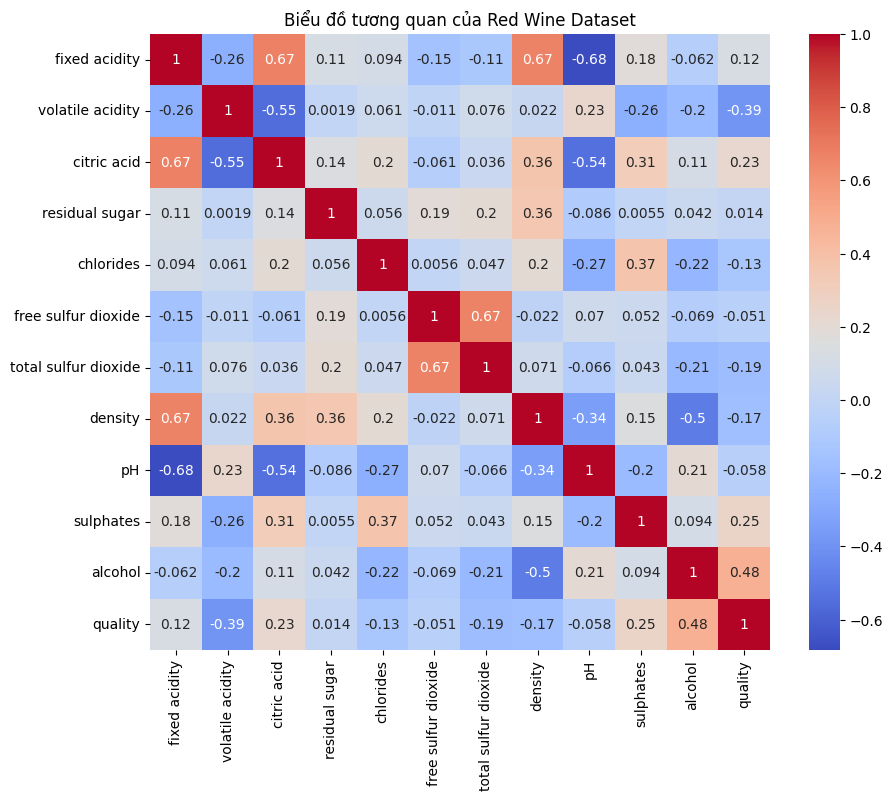

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_red, annot=True, cmap="coolwarm")
plt.title("Biểu đồ tương quan của Red Wine Dataset")
plt.show()

In [30]:
corr_red["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

Ta chọn ra 4 thành phần có sự tương quan mạnh với xếp loại độ ngon của rượu
Từ ma trận tương quan, có thể thấy rằng alcohol có tương quan dương mạnh nhất với quality (0.476). Điều này cho thấy các loại rượu có nồng độ cồn cao hơn thường có chất lượng tốt hơn.

Ngược lại, volatile acidity có tương quan âm khá mạnh với quality (-0.391). Điều này cho thấy độ axit bay hơi cao có thể làm giảm chất lượng rượu.

Ngoài ra, sulphates cũng có tương quan dương vừa phải với quality (0.251), cho thấy sulphates có thể góp phần cải thiện chất lượng rượu.

Phần lớn các biến khác như residual sugar, free sulfur dioxide và pH có hệ số tương quan gần bằng 0, cho thấy chúng không ảnh hưởng nhiều đến chất lượng rượu trong bộ dữ liệu này.

In [ ]:
#Lấy tam giác trên của ma trận tương quan để loại bỏ đường chéo chính (self-correlation) và các cặp giá trị trùng lặp do tính đối xứng của ma trận.

upper_red = corr_red.where(np.triu(np.ones(corr_red.shape), k=1).astype(bool))
# lọc các cặp thành phần tương quan  >= 0.5
high_corr_red = upper_red.stack().reset_index()
high_corr_red.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_red = high_corr_red[abs(high_corr_red['Correlation']) >= 0.5]
print(high_corr_red)      

              Feature 1             Feature 2  Correlation
2         fixed acidity           citric acid     0.671703
7         fixed acidity               density     0.668047
8         fixed acidity                    pH    -0.682978
14     volatile acidity           citric acid    -0.552496
32          citric acid                    pH    -0.541904
66  free sulfur dioxide  total sulfur dioxide     0.667666


Từ kết quả phân tích ma trận tương quan (|correlation| ≥ 0.5), ta nhận thấy một số cặp biến có mối quan hệ tương đối mạnh:

Fixed acidity và citric acid có tương quan dương khá mạnh (0.67), cho thấy khi độ axit cố định tăng thì lượng axit citric cũng có xu hướng tăng.

Fixed acidity và density có tương quan dương (0.67), điều này cho thấy khi nồng độ axit cố định tăng thì mật độ của rượu cũng tăng theo.

Fixed acidity và pH có tương quan âm mạnh (-0.68). Điều này hợp lý vì độ axit cao thường làm giảm giá trị pH của dung dịch.

Volatile acidity và citric acid có tương quan âm (-0.55), cho thấy hai loại axit này có xu hướng biến đổi theo hướng ngược nhau.

Citric acid và pH có tương quan âm (-0.54), nghĩa là khi lượng axit citric tăng thì giá trị pH có xu hướng giảm.

Free sulfur dioxide và total sulfur dioxide có tương quan dương mạnh (0.67) do tổng sulfur dioxide bao gồm cả phần sulfur dioxide tự do.